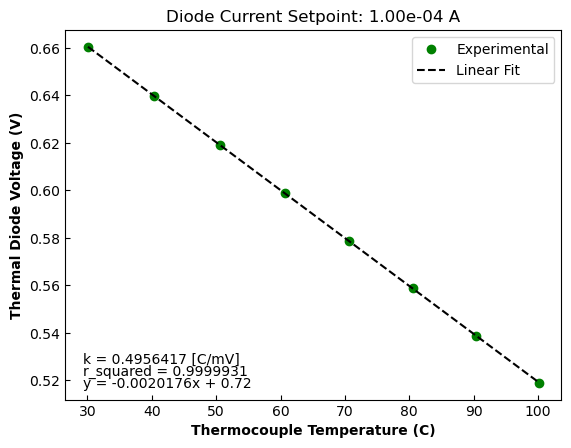

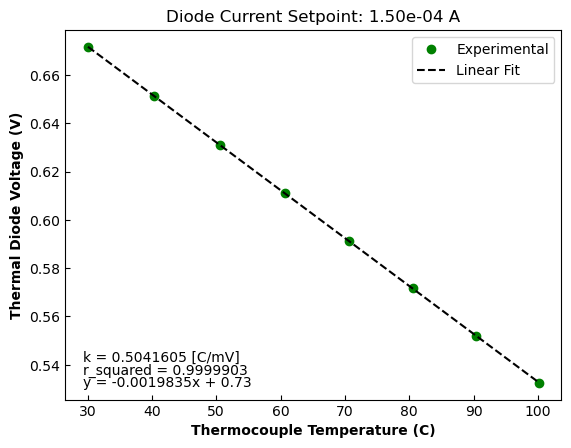

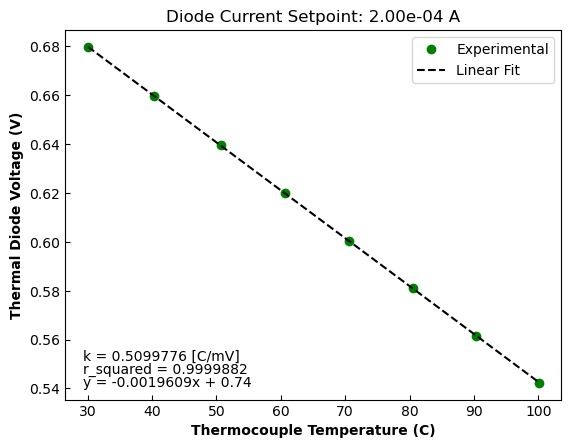

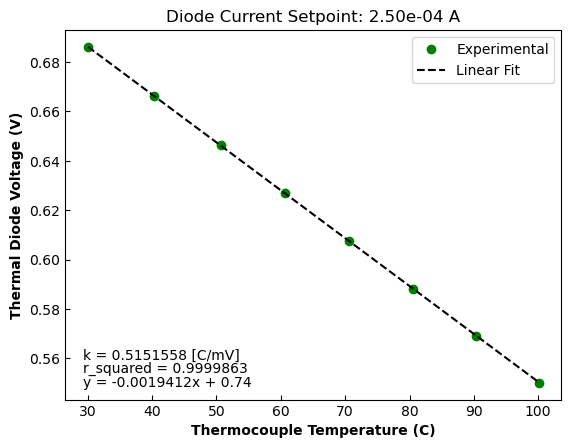

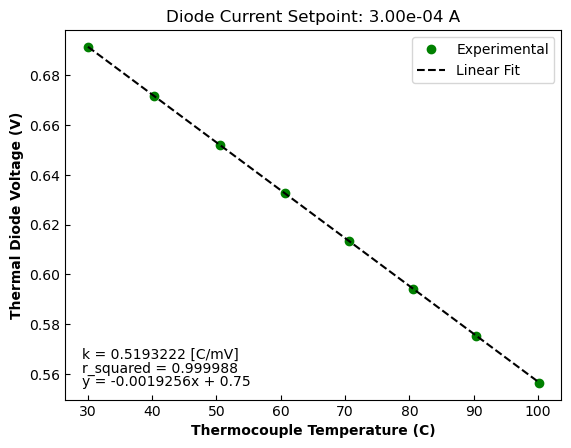

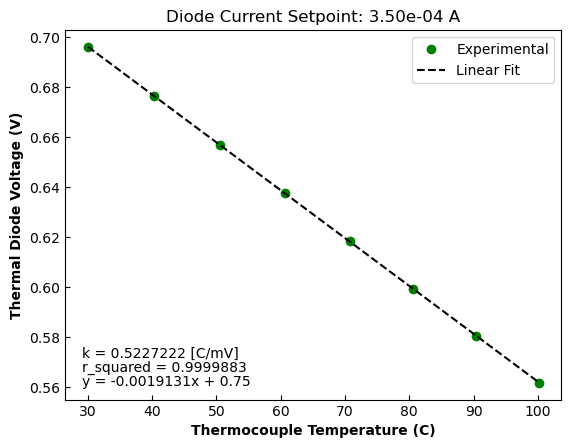

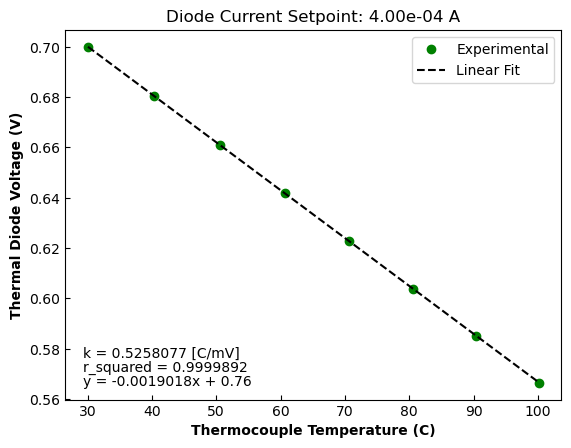

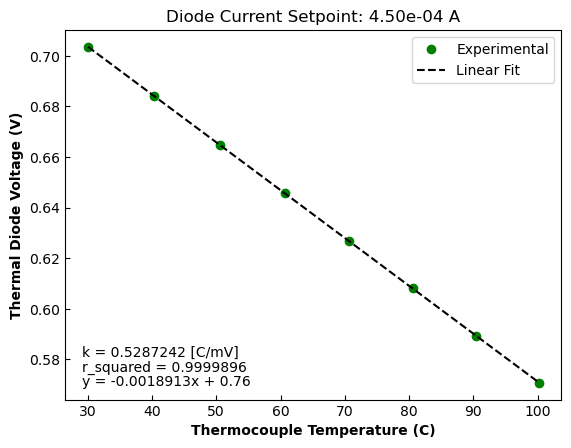

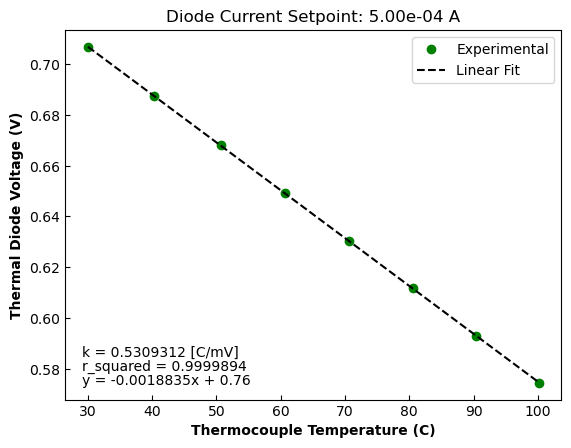

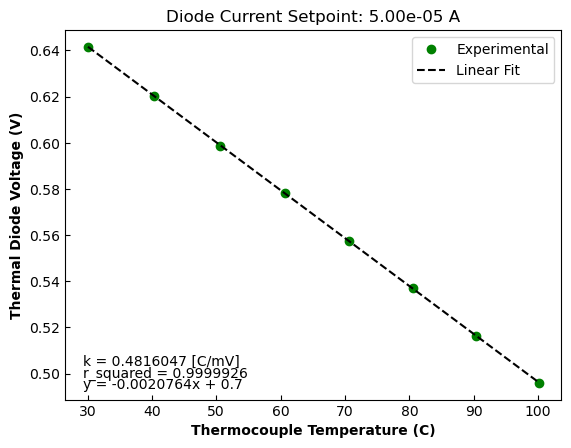

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import os 
import glob
import numpy as np
from sklearn.metrics import r2_score
import sys
sys.path.insert(1, 'C:\\Users\\pmlbl\\Arceus\\utils')
import DataDirectory
#from utils.DataDirectory import DataDirectory
import time

#set folder directory
#path = 'C:\\Lab_Data\\Data\\20250717\\D000'
path = 'C:\\Lab_Data\\Data\\20250724\\D001'

#Run this if you're plotting more than 1 figure (e.g. current setpoint sweep)
dd = DataDirectory.DataDirectory(directory = path, key='Iset')
dd.file_organizer() ## organizes all files in respective current set point
time.sleep(5) #gives time for new directories to udpate before being read below
subs = dd.sub_dirs() ## identifies all immediate sub directories to iterate over

#iterate through all files in folder
def get_csvs(path):
    csvs = glob.glob(os.path.join(path, "*.csv"))
    return csvs

#extract Tset from each file
def get_setpoint(path,key):
    split_str = path.split('_')
    try:
        index = split_str.index(key)
    except ValueError:
        print(split_str)
        print(f"'{key}' is not found in the list.")
    setpoint = split_str[index+1]
    return setpoint

#average the data points for each Tset file
def get_value(f):
    df = pd.read_csv(f,names=['time','value'])
    avg_value = df.value.mean()
    return avg_value

#iterate through files and obtain unique Tsets
def get_tsets(path):
    arr = []
    for f in get_csvs(path):
        sp = get_setpoint(f,key='TsetC')
        arr.append(float(sp))
    arr = np.unique(arr)
    return arr

#iterate through files and insert values for given setpoint
for sub in subs:
    p = path + '\\' + sub
    df = pd.DataFrame(index=get_tsets(path),columns=['Temp','Volts']) #create global df with tsets as index
    for f in get_csvs(p):
        if 'Temp' in f:
            avg_temp = get_value(f)
            setpoint = get_setpoint(f,key='TsetC')
            df.loc[float(setpoint),'Temp'] = avg_temp
        elif 'Volt' in f:
            avg_volt = get_value(f)
            setpoint = get_setpoint(f,key='TsetC')
            df.loc[float(setpoint),'Volts'] = avg_volt
        else:
            pass

    #include linear regression fit, include equation of line on plot
    x = list(df.Temp)
    y = list(df.Volts)
    coef = np.polyfit(x,y,1)
    poly1d_fn = np.poly1d(coef)
    r2 = r2_score(y, poly1d_fn(x))

    #Plotting
    fig, ax = plt.subplots()
    ax.plot(x,y, 'go', x, poly1d_fn(x), '--k') #'--k'=black dashed line
    ax.tick_params(direction='in')
    ax.set_xlabel('Thermocouple Temperature (C)', fontweight='bold')
    ax.set_ylabel('Thermal Diode Voltage (V)', fontweight='bold')
    ax.legend(['Experimental', 'Linear Fit'])
    ax.text(ax.get_xlim()[0]*1.1,ax.get_ylim()[0]*1.01,'y = {}x + {}'.format(round(coef[0],7),round(coef[1],2))) #need to fix the text placement to be dependent on the axis location not with respective to data
    ax.text(ax.get_xlim()[0]*1.1,ax.get_ylim()[0]*1.02, 'r_squared = {}'.format(round(r2,7)))
    ax.text(ax.get_xlim()[0]*1.1,ax.get_ylim()[0]*1.03, 'k = {} [C/mV]'.format(abs(round((1/(1000*coef[0])),7))))
    # ax.set_title('100uA Constant Diode Current Setpoint')
    ax.set_title('Diode Current Setpoint: {} A'.format(sub.split('_')[1]))
    fig.savefig(p + 'figure.png')